Analyize and Visualize Sentiment Patterns in Social Media to understand public opinion nad attitude towards specific topics or brand.

In [ ]:
!pip install wordcloud nltk textblob seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from textblob import TextBlob

import nltk
import re

nltk.download('stopwords')

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df = pd.read_csv('/content/twitter_training.csv')

df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [ ]:
df.isnull().sum()

,0
2401,0
Borderlands,0
Positive,0
"im getting on borderlands and i will murder you all ,",686


In [ ]:
df.columns = ['ID','Brand','Sentiment','Tweet']

In [ ]:
df.dropna(inplace=True)

def clean_text(text):
    text = re.sub(r'http\S+','',str(text))
    text = re.sub(r'@\w+','',text)
    text = re.sub(r'#\w+','',text)
    text = re.sub(r'[^a-zA-Z ]','',text)
    text = text.lower()
    return text

df['Clean_Tweet'] = df['Tweet'].apply(clean_text)

1.Sentiment Distribution

/tmp/ipykernel_6955/427611043.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


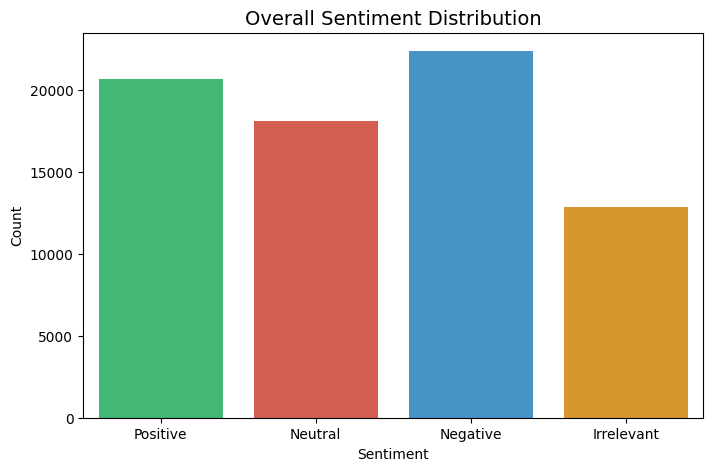

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Sentiment',
    data=df,
    palette=['#2ECC71','#E74C3C','#3498DB','#F39C12']
)

plt.title('Overall Sentiment Distribution', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Count')

plt.show()

2. Brand-wise Sentiment

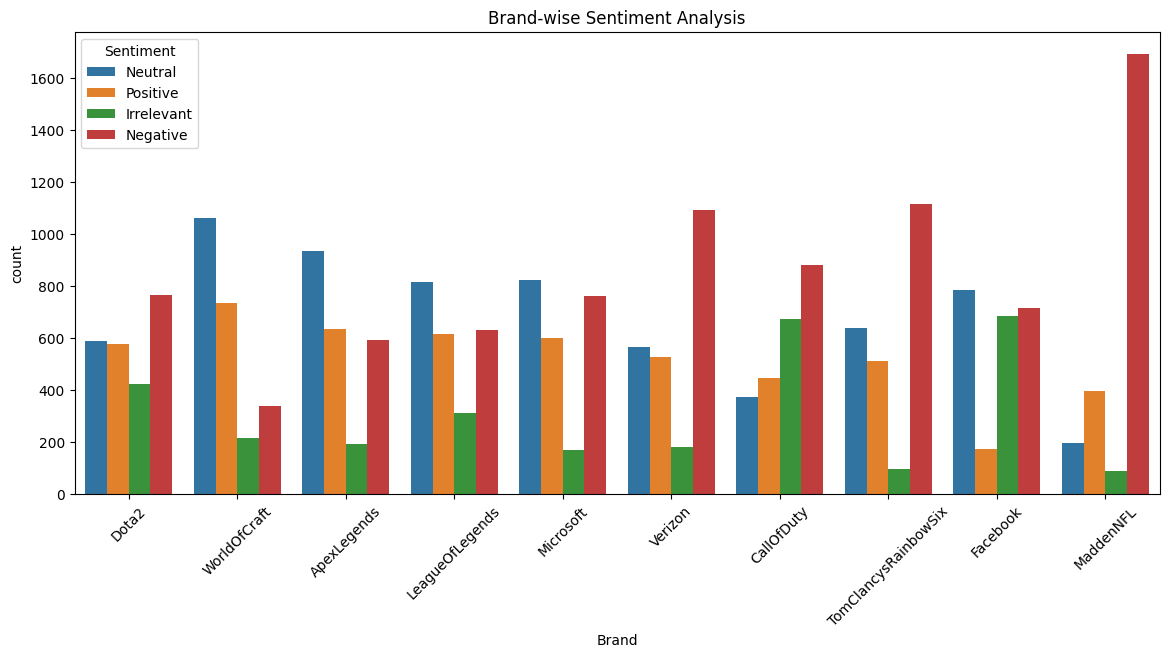

In [ ]:
top_brands = df['Brand'].value_counts().head(10).index

brand_df = df[df['Brand'].isin(top_brands)]

plt.figure(figsize=(14,6))

sns.countplot(
    x='Brand',
    hue='Sentiment',
    data=brand_df
)

plt.xticks(rotation=45)

plt.title('Brand-wise Sentiment Analysis')
plt.show()

3. Sentiment Percentage Pie Chart

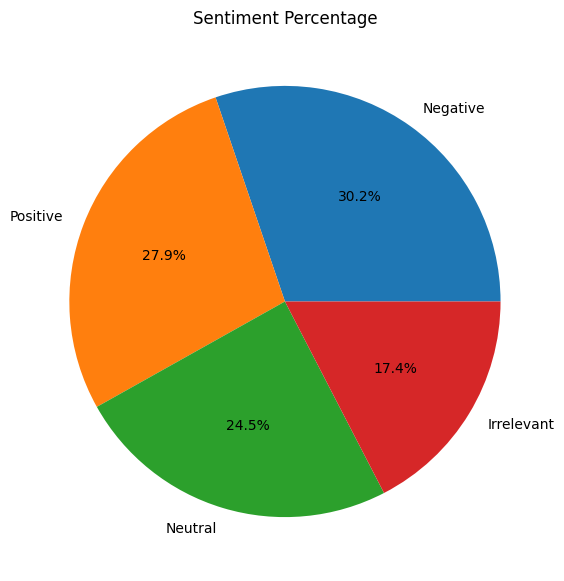

In [ ]:
sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title('Sentiment Percentage')
plt.show()

4.Positive Word Cloud

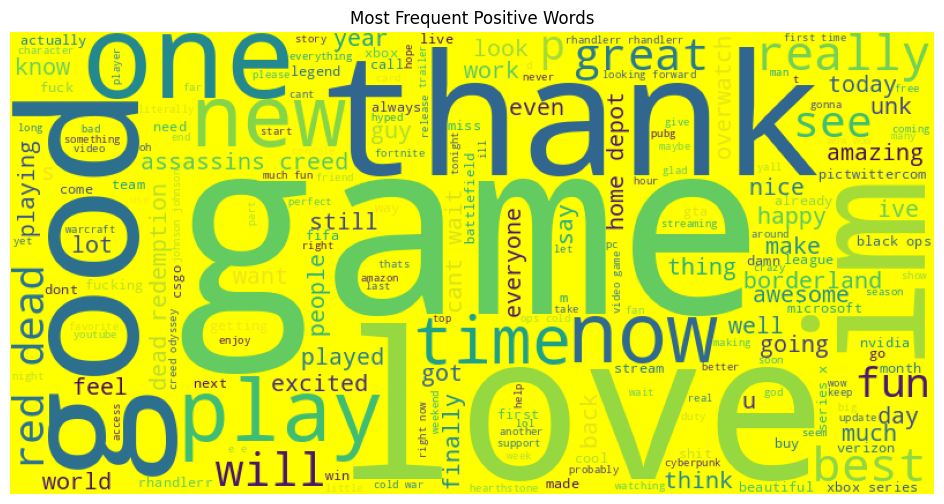

In [ ]:
positive_text = " ".join(
    df[df['Sentiment']=="Positive"]['Clean_Tweet']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='yellow'
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Most Frequent Positive Words")
plt.show()

5.Negative Word Cloud

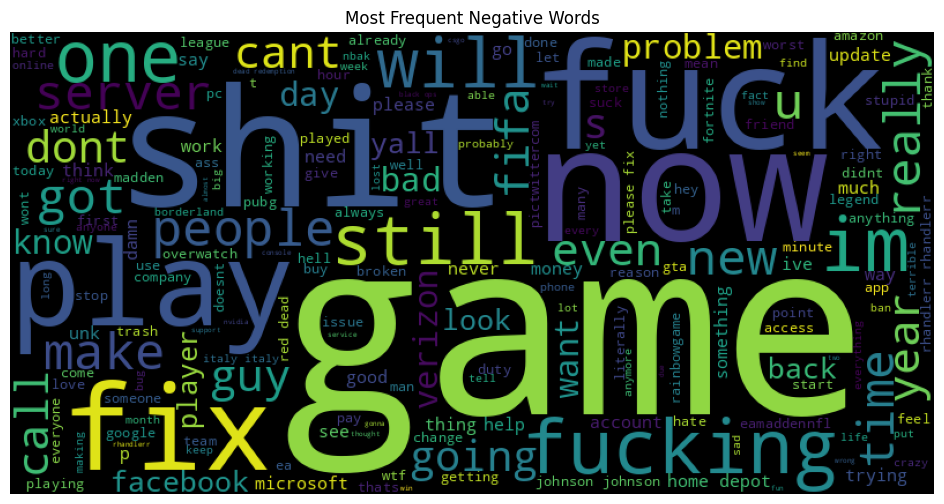

In [ ]:

negative_text = " ".join(
    df[df['Sentiment']=="Negative"]['Clean_Tweet']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black'
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Most Frequent Negative Words")
plt.show()

6. Top Mentioned Brands

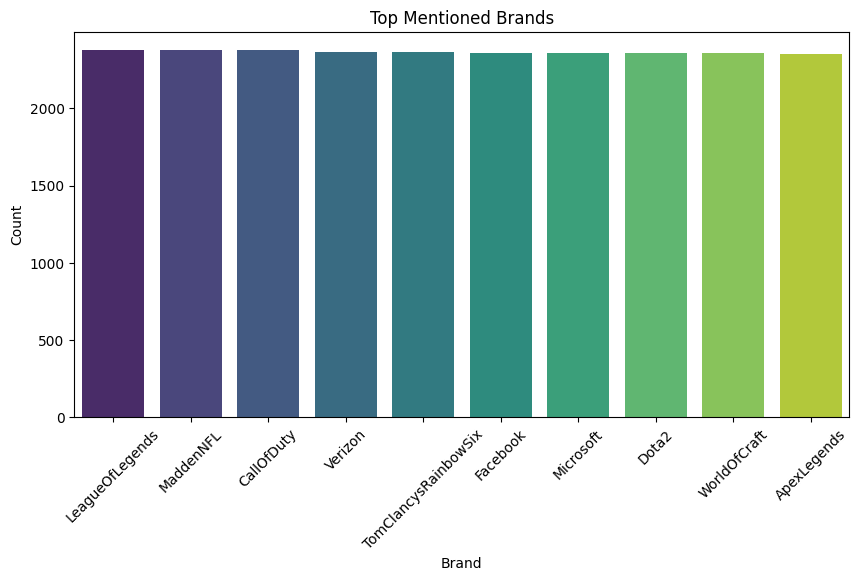

In [ ]:
top = df['Brand'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top.index,
    y=top.values,
    hue=top.index,
    palette='viridis',
    legend=False
)

plt.xticks(rotation=45)
plt.title("Top Mentioned Brands")
plt.xlabel("Brand")
plt.ylabel("Count")

plt.show()

7.Sentiment Heatmap

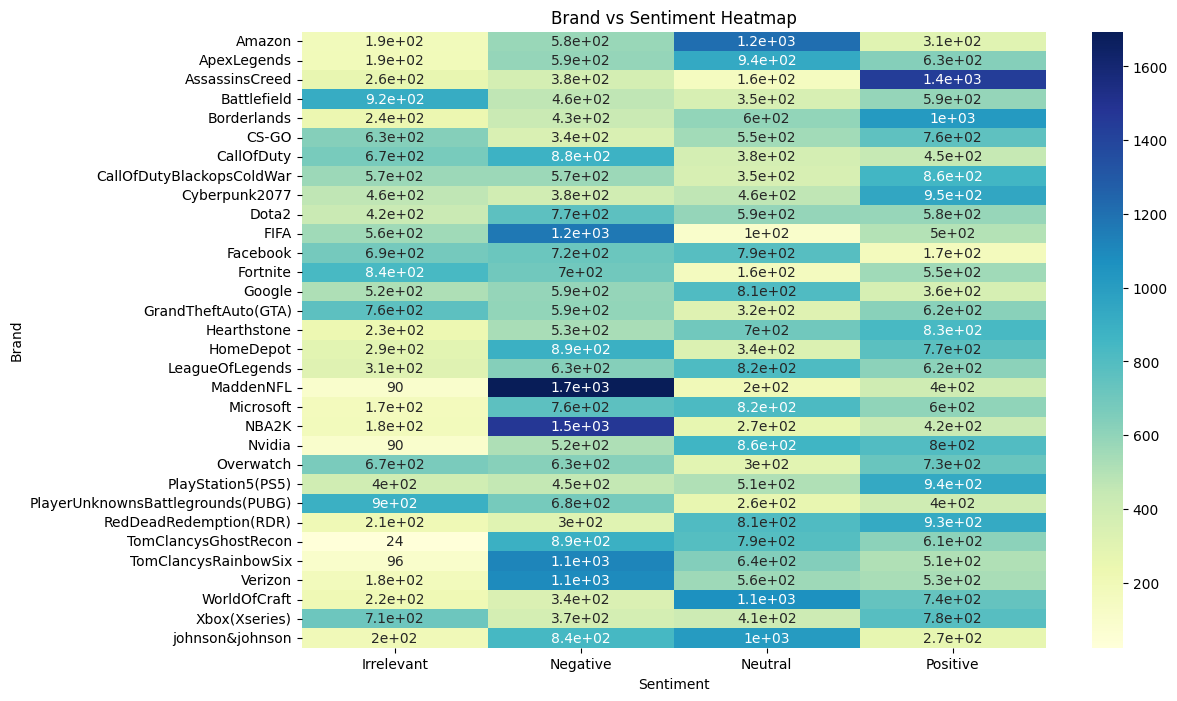

In [ ]:
heatmap_data = pd.crosstab(
    df['Brand'],
    df['Sentiment']
)

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='YlGnBu'
)

plt.title('Brand vs Sentiment Heatmap')
plt.show()